Accuracy: 0.9109663409337676

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.92      0.93       558
           1       0.88      0.89      0.89       363

    accuracy                           0.91       921
   macro avg       0.91      0.91      0.91       921
weighted avg       0.91      0.91      0.91       921



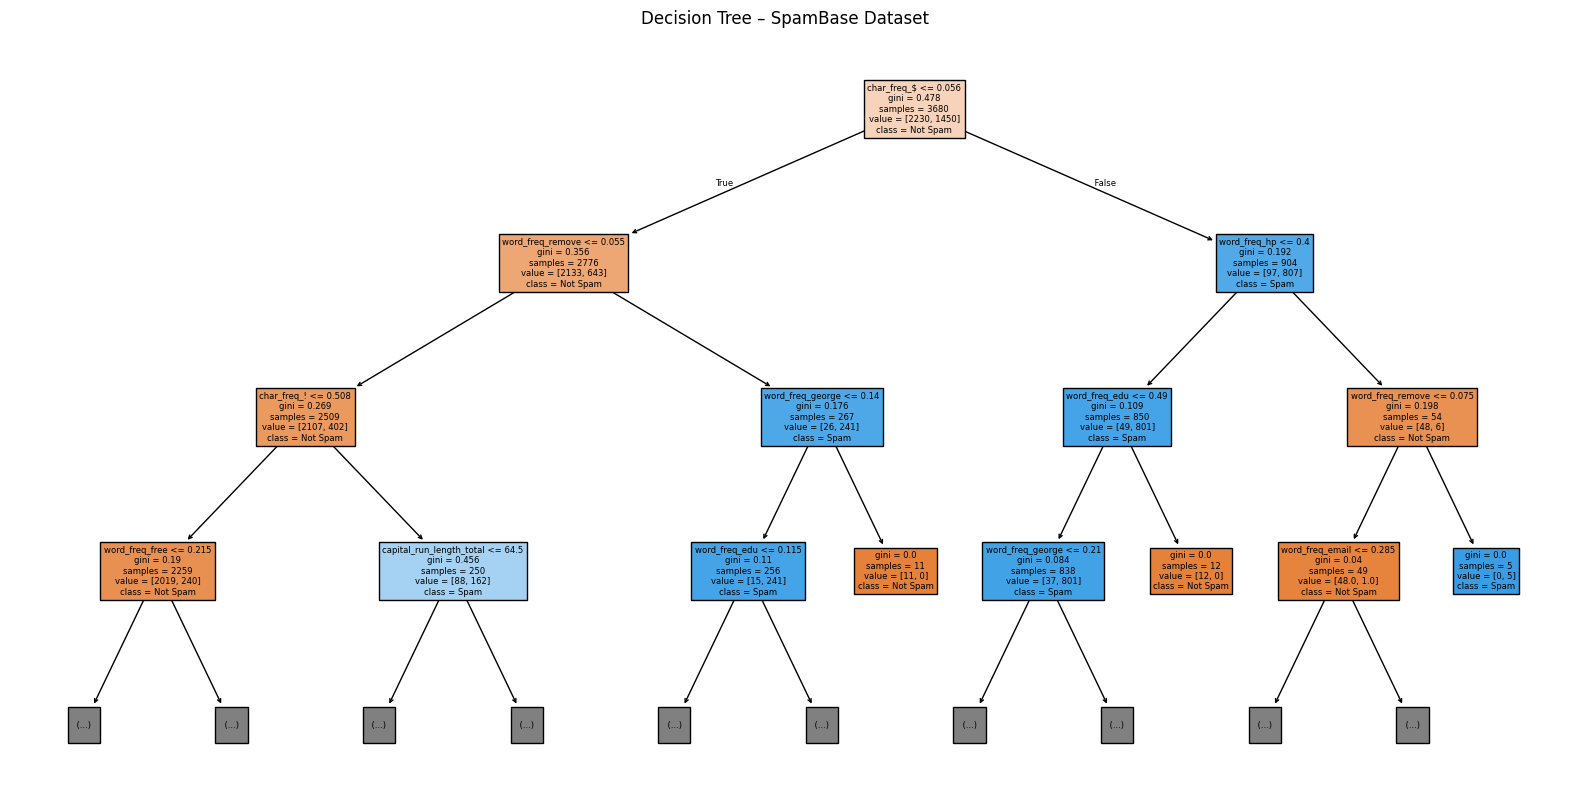

In [12]:
# Decision Tree on SpamBase Dataset
# ABSOLUTE PATH FIX — required because cwd = "/"

import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# -----------------------------
# SET PROJECT ROOT EXPLICITLY
# -----------------------------

PROJECT_ROOT = "/home/midori/Desktop/Machine-Learning"

DATA_DIR = os.path.join(PROJECT_ROOT, "Data")
SPAM_PATH = os.path.join(DATA_DIR, "spambase.csv")

# -----------------------------
# Load dataset
# -----------------------------

df = pd.read_csv(SPAM_PATH)

# -----------------------------
# Features and target
# -----------------------------

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# -----------------------------
# Train-test split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# Train Decision Tree
# -----------------------------

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# -----------------------------
# Evaluation
# -----------------------------

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# -----------------------------
# Tree Visualization (DISPLAY ONLY)
# -----------------------------

plt.figure(figsize=(20, 10))
plot_tree(
    model,
    max_depth=3,
    filled=True,
    feature_names=X.columns,
    class_names=["Not Spam", "Spam"]
)
plt.title("Decision Tree – SpamBase Dataset")
plt.show()
